In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [32]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

folders = [dataZ, dataO, dataN, dataF, dataS]
filenames = ['Z', 'O', 'N', 'F', 'S']
df_filenames = ['Z.csv', 'O.csv', 'N.csv', 'F.csv', 'S.csv']

dfZ = pd.read_csv('Z.csv')
dfO = pd.read_csv('O.csv')
dfN = pd.read_csv('N.csv')
dfF = pd.read_csv('F.csv')
dfS = pd.read_csv('S.csv')

In [33]:
dfN.shape
print(dfZ.shape[0])

time = np.linspace(0,23.6,4097)

dfZ['time'] = time

dfZ.head()

4097


C:\Users\Rwen\AppData\Local\Temp\ipykernel_4120\3072494388.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfZ['time'] = time


,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,time
0,12,-56,-37,-31,14,-87,-2,-31,8,-41,...,40,-19,-45,6,-133,-3,-51,56,-36,0.000000
1,22,-50,-22,-43,26,-89,20,-16,17,-38,...,48,-1,-62,-6,-144,-3,-42,55,-71,0.005762
2,35,-64,-17,-39,32,-73,42,10,29,-31,...,35,33,-76,-8,-113,-12,-39,38,-120,0.011523
3,45,-91,-24,-39,25,-69,48,28,46,-25,...,5,51,-98,-6,-74,-24,-47,-5,-150,0.017285
4,69,-135,-31,-9,16,-51,27,31,50,-32,...,-40,49,-108,15,-41,-34,-51,-47,-160,0.023047


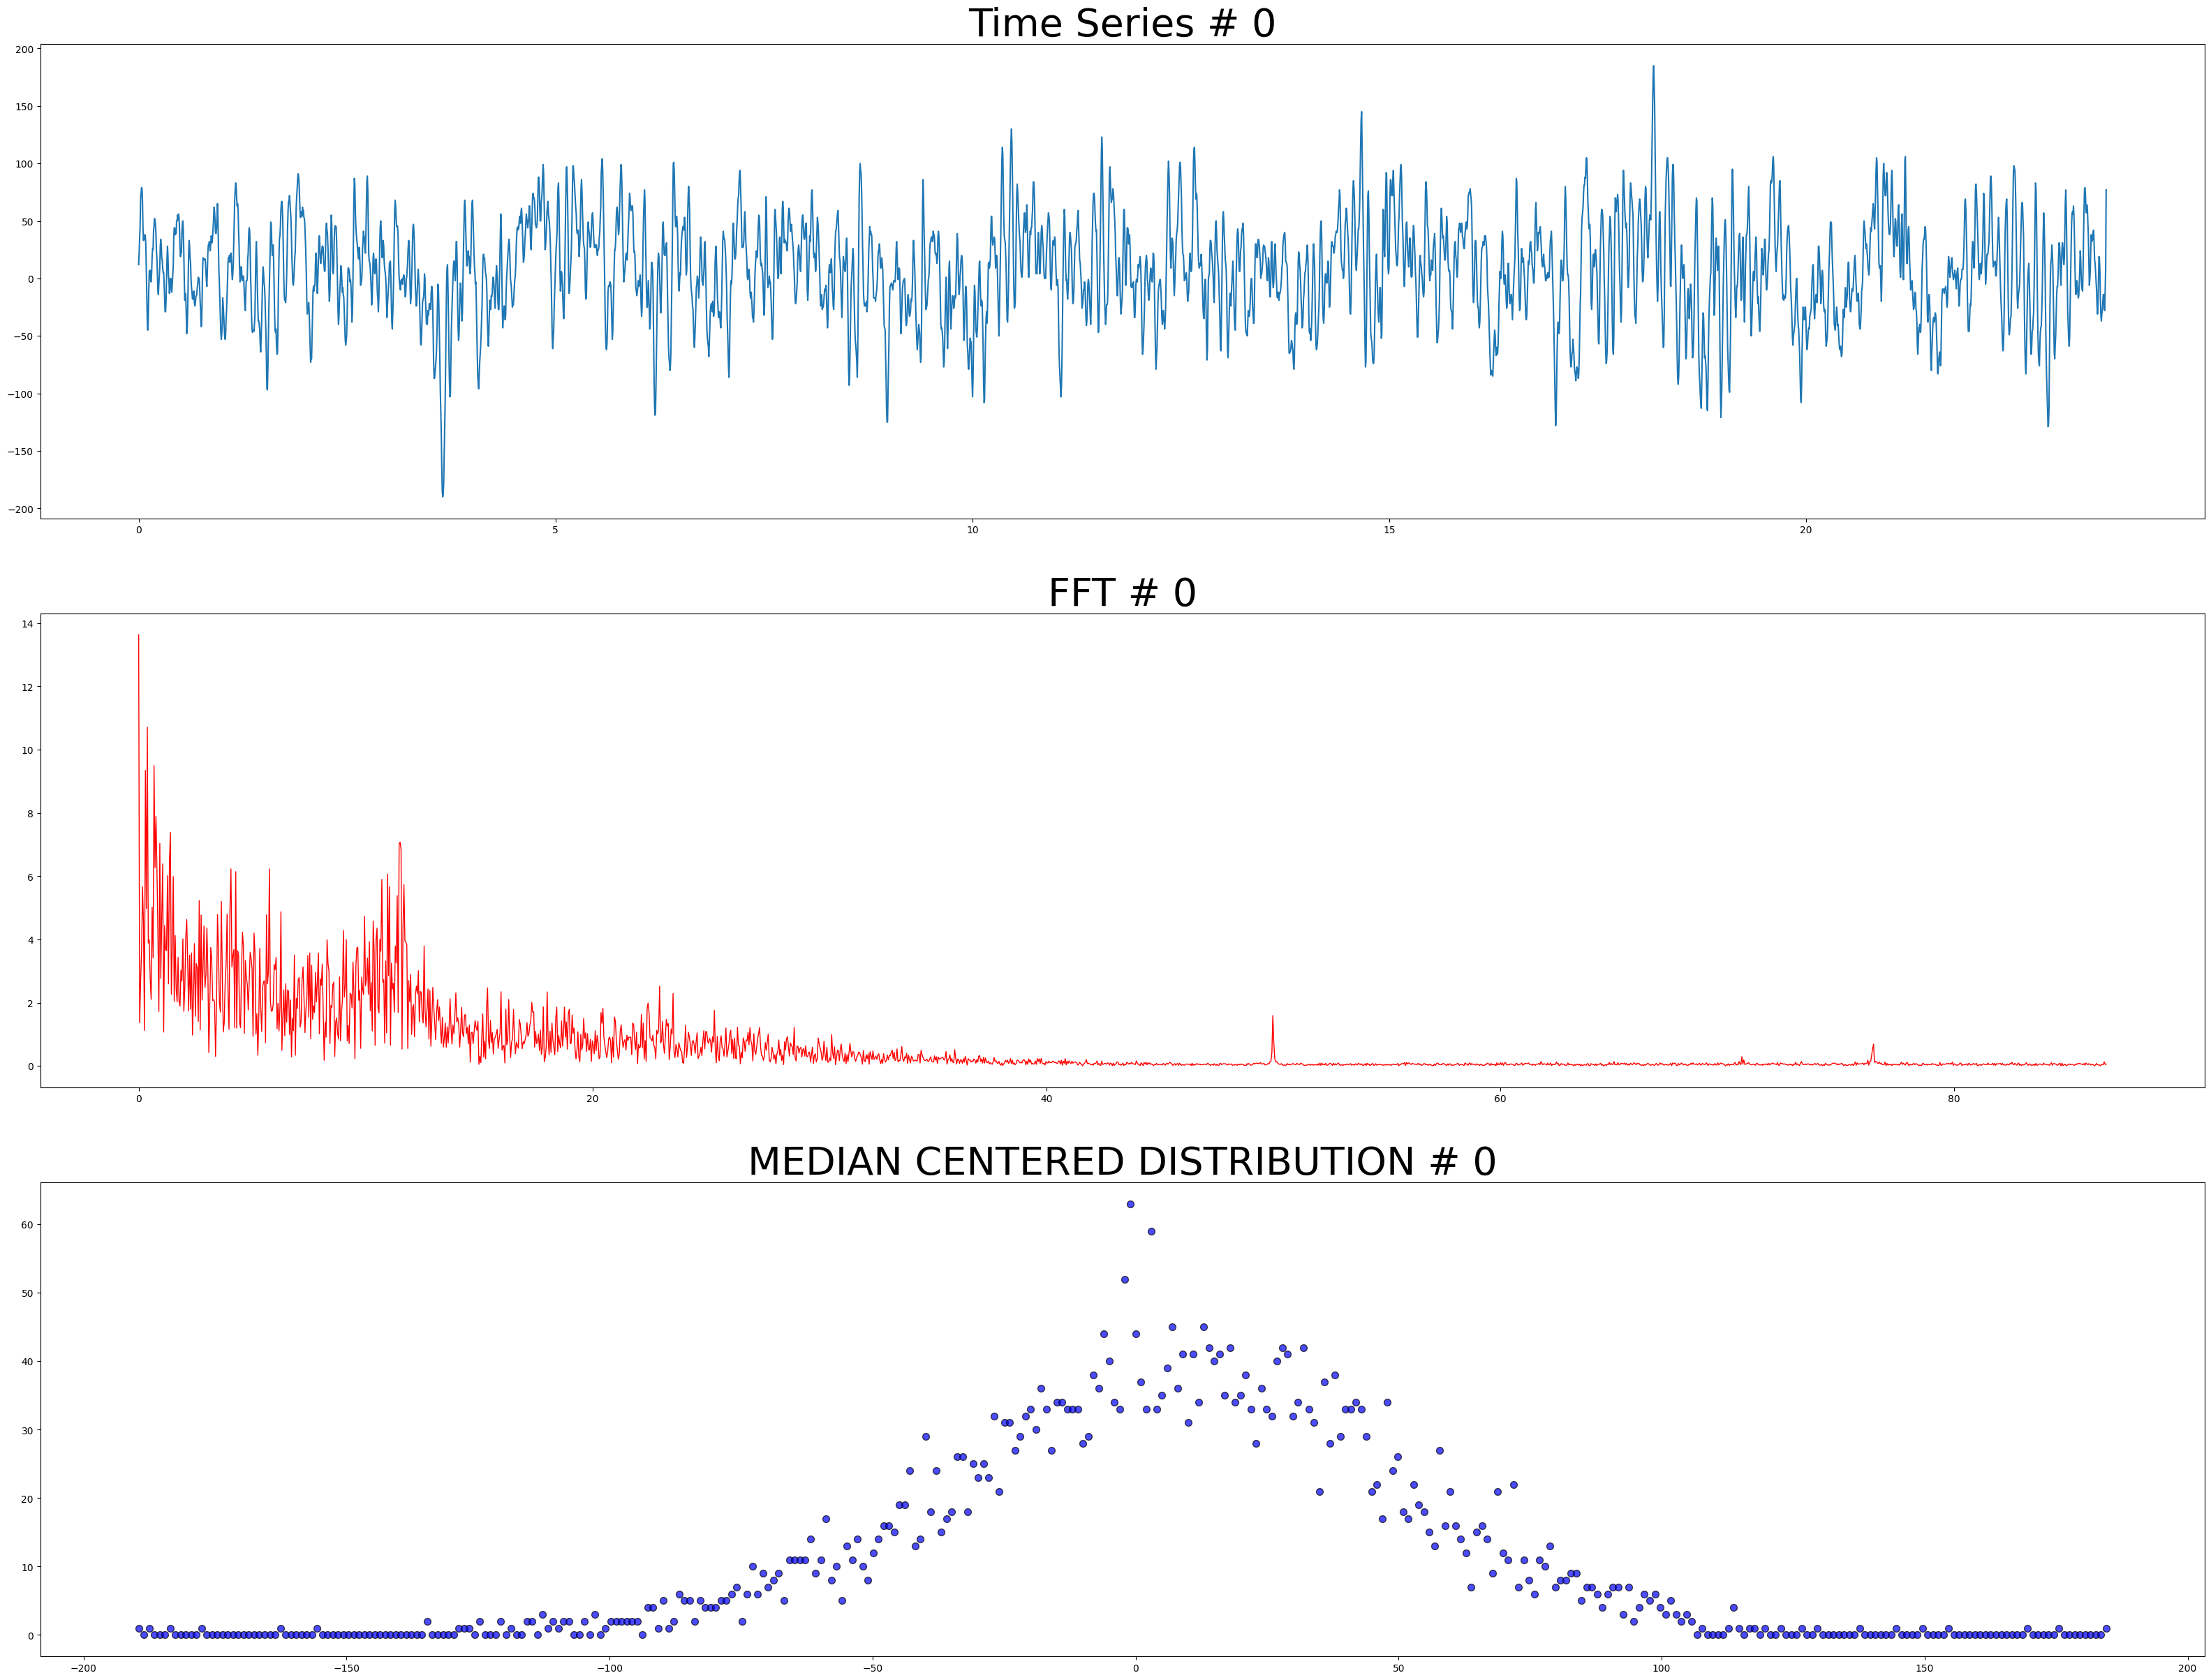

In [69]:
n = 0
fig, axs = plt.subplots(3, figsize=(40,30))
axs[0].set_title(f'Time Series # {n}', fontsize=40)
axs[0].plot(dfZ['time'],dfZ[f'{n}'])

# FFT

fft_values = fft(dfZ[f'{n}'].values)  # Compute FFT
fft_magnitude = np.abs(fft_values)  # Magnitude (amplitude)
fft_phase = np.angle(fft_values)  # Phase angle

sample_spacing = dfZ['time'].iloc[1] - dfZ['time'].iloc[0]  # Time step
frequencies = fftfreq(4097, sample_spacing)
positive_freqs = frequencies[:4097//2]
positive_magnitude = fft_magnitude[:4097//2] * 2 / 4097  

axs[1].set_title(f'FFT # {n}', fontsize=40)
axs[1].plot(positive_freqs, positive_magnitude, 'r-', linewidth=1)

# HISTOGRAM
bins = dfZ[f'{n}'].max() - dfZ[f'{n}'].min() + 1
counts, bin_edges = np.histogram(dfZ[f'{n}'].values, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

axs[2].set_title(f'MEDIAN CENTERED DISTRIBUTION # {n}', fontsize=40)
axs[2].scatter(bin_centers, counts, s=50, c='blue', alpha=0.7, edgecolors='black')


plt.show()

In [50]:
print(fft_values)

[27927.           -0.j         -2486.0495057 -1274.24694955j
 -2860.06406088-4620.6155212j  ...  3495.3483902 -6450.78710826j
 -2860.06406088+4620.6155212j  -2486.0495057 +1274.24694955j]


In [67]:
a = np.arange(dfZ['0'].min(),dfZ['0'].max() + 1,1)
a

array([-190, -189, -188, -187, -186, -185, -184, -183, -182, -181, -180,
       -179, -178, -177, -176, -175, -174, -173, -172, -171, -170, -169,
       -168, -167, -166, -165, -164, -163, -162, -161, -160, -159, -158,
       -157, -156, -155, -154, -153, -152, -151, -150, -149, -148, -147,
       -146, -145, -144, -143, -142, -141, -140, -139, -138, -137, -136,
       -135, -134, -133, -132, -131, -130, -129, -128, -127, -126, -125,
       -124, -123, -122, -121, -120, -119, -118, -117, -116, -115, -114,
       -113, -112, -111, -110, -109, -108, -107, -106, -105, -104, -103,
       -102, -101, -100,  -99,  -98,  -97,  -96,  -95,  -94,  -93,  -92,
        -91,  -90,  -89,  -88,  -87,  -86,  -85,  -84,  -83,  -82,  -81,
        -80,  -79,  -78,  -77,  -76,  -75,  -74,  -73,  -72,  -71,  -70,
        -69,  -68,  -67,  -66,  -65,  -64,  -63,  -62,  -61,  -60,  -59,
        -58,  -57,  -56,  -55,  -54,  -53,  -52,  -51,  -50,  -49,  -48,
        -47,  -46,  -45,  -44,  -43,  -42,  -41,  -

In [61]:
a = np.arange(0,10,1)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])